In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv('HR_comma_sep.csv')

# Look at the first few rows to understand the structure
print(df.head())

# Group the data by the 'left' column and find the average of all other numeric columns
# This shows us the average stats of employees who stayed (0) vs left (1)
print(df.groupby('left').mean(numeric_only=True))

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

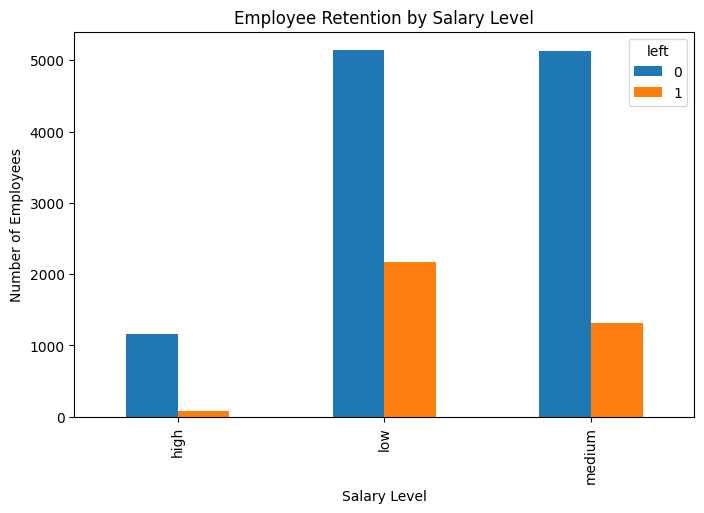

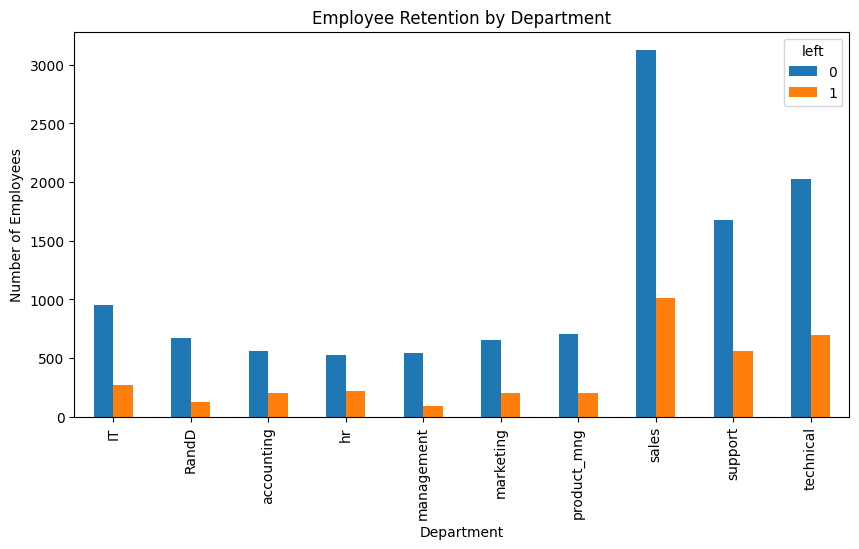

In [7]:
import matplotlib.pyplot as plt

# 2. Impact of employee salaries on retention
pd.crosstab(df['salary'], df['left']).plot(kind='bar', figsize=(8,5))
plt.title('Employee Retention by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Number of Employees')
plt.show()

# 3. Correlation between department and employee retention
pd.crosstab(df['Department'], df['left']).plot(kind='bar', figsize=(10,5))
plt.title('Employee Retention by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Isolate the important variables
subdf = df[['satisfaction_level', 'average_montly_hours', 'promotion_last_5years', 'salary']]

# Convert the text 'salary' column into numerical dummy variables
salary_dummies = pd.get_dummies(subdf['salary'], prefix="salary")

# Combine our isolated data with the new dummy variables
df_with_dummies = pd.concat([subdf, salary_dummies], axis='columns')

# Drop the original text column as it's no longer needed
df_with_dummies.drop('salary', axis='columns', inplace=True)

# Define X (the features/input) and Y (the target/output)
X = df_with_dummies
y = df['left']

# Split the data into a training set (80%) and a testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the model
model = LogisticRegression(max_iter=1000) # max_iter increased to ensure the math converges
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [11]:
# Measure the accuracy
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 76.20%
